# Spotify Genre Classification – Exploratory Data Analysis

In this notebook, we perform an exploratory analysis of the Spotify Tracks Genre dataset to understand its structure, assess its quality, and identify the characteristics of the available features.

The objective is to gain a better understanding of the dataset before developing and evaluating machine learning models for the genre classification task.

## Load and Inspect the Dataset

The dataset is loaded and its basic structure is examined, including the number of samples, features, variable names, and data types.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

In [2]:
root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
local_data_path = root / 'data' / 'spotify_genre_classification.csv'

if local_data_path.exists():
    data_path = local_data_path
else:
    dataset_path = Path(kagglehub.dataset_download('thedevastator/spotify-tracks-genre-dataset'))
    csv_files = sorted(dataset_path.rglob('*.csv'))

    if len(csv_files) == 0:
        raise FileNotFoundError('No CSV files were found in the downloaded Kaggle dataset.')

    data_path = csv_files[0]

print('Path to dataset file:', data_path)

df = pd.read_csv(data_path)
df.head()

Path to dataset file: /Users/enolariasalvarez/.cache/kagglehub/datasets/thedevastator/spotify-tracks-genre-dataset/versions/1/train.csv


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
# The dataset was loaded in the previous cell.
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
print('Number of samples:', df.shape[0])
print('Number of variables:', df.shape[1])

Number of samples: 114000
Number of variables: 21


In [5]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

## Data Quality Assessment

The dataset is checked for missing values, duplicate records, and descriptive statistics to ensure its quality and suitability for subsequent analysis and model training.

In [7]:
missing = df.isnull().sum()
missing[missing > 0]

artists       1
album_name    1
track_name    1
dtype: int64

In [8]:
n_duplicates = df.duplicated().sum()
print('Duplicated rows:', n_duplicates)

Duplicated rows: 0


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


## Target Variable

The target variable for this classification task is **`track_genre`**, which represents the musical genre assigned to each track.

This variable contains **114 balanced classes**, making the problem a large-scale multiclass classification task.

In [10]:
target_name = 'track_genre'

if target_name not in df.columns:
    raise ValueError('Target column not found. Check the dataset columns.')

In [11]:
Y = df[target_name]

print('Number of classes:', Y.nunique())
Y.value_counts().head(20)

Number of classes: 114


track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000
new-age              1000
mpb                  1000
minimal-techno       1000
metalcore            1000
metal                1000
mandopop             1000
malay                1000
latino               1000
latin                1000
kids                 1000
Name: count, dtype: int64

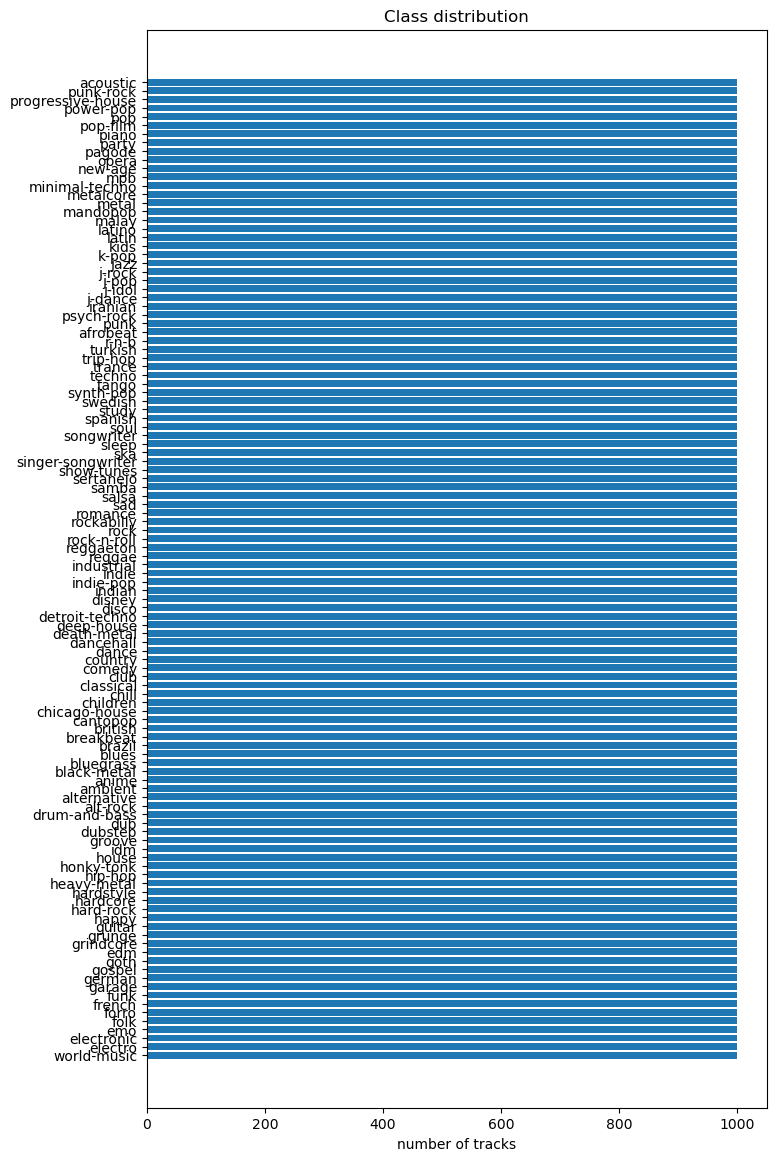

In [12]:
counts = Y.value_counts()

plt.figure(figsize=(8, 14))
plt.barh(counts.index, counts.values)
plt.xlabel('number of tracks')
plt.title('Class distribution')
plt.gca().invert_yaxis()
plt.show()

The class distribution is important because a classifier can obtain a misleading accuracy if some genres are much more frequent than others.

## Select the Input Features

The input variables are selected from the numerical audio features provided by the dataset. These features can be directly used by the evaluated machine learning models and capture relevant musical characteristics such as energy, danceability, loudness, tempo, and acousticness.

Textual metadata and identifier columns are excluded, as they are not suitable for generalizing to unseen tracks.

In [13]:
numeric_names = df.select_dtypes(include=np.number).columns.tolist()
numeric_names

['Unnamed: 0',
 'popularity',
 'duration_ms',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

In [14]:
# Remove identifiers if they appear as numerical variables.
drop_names = ['Unnamed: 0']
feature_names = [name for name in numeric_names if name not in drop_names]

X = df[feature_names].values

print('X shape:', X.shape)
print('Y shape:', Y.shape)

X shape: (114000, 14)
Y shape: (114000,)


In [15]:
df[feature_names].describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996
instrumentalness,114000.0,0.156050,0.309555,0.000,0.00000,0.000042,0.0490,1.000


## Explore the Distribution of Numerical Features

Histograms are used to examine the distribution of each numerical feature. This helps identify differences in scale, skewness, and variability, providing a better understanding of the data before training the machine learning models.

In [16]:
def plot_histograms(df, feature_names):
    n_features = len(feature_names)
    n_cols = 3
    n_rows = int(np.ceil(n_features / n_cols))

    plt.figure(figsize=(12, 3 * n_rows))

    for i, name in enumerate(feature_names):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.hist(df[name].dropna(), bins=30)
        plt.title(name)

    plt.tight_layout()
    plt.show()

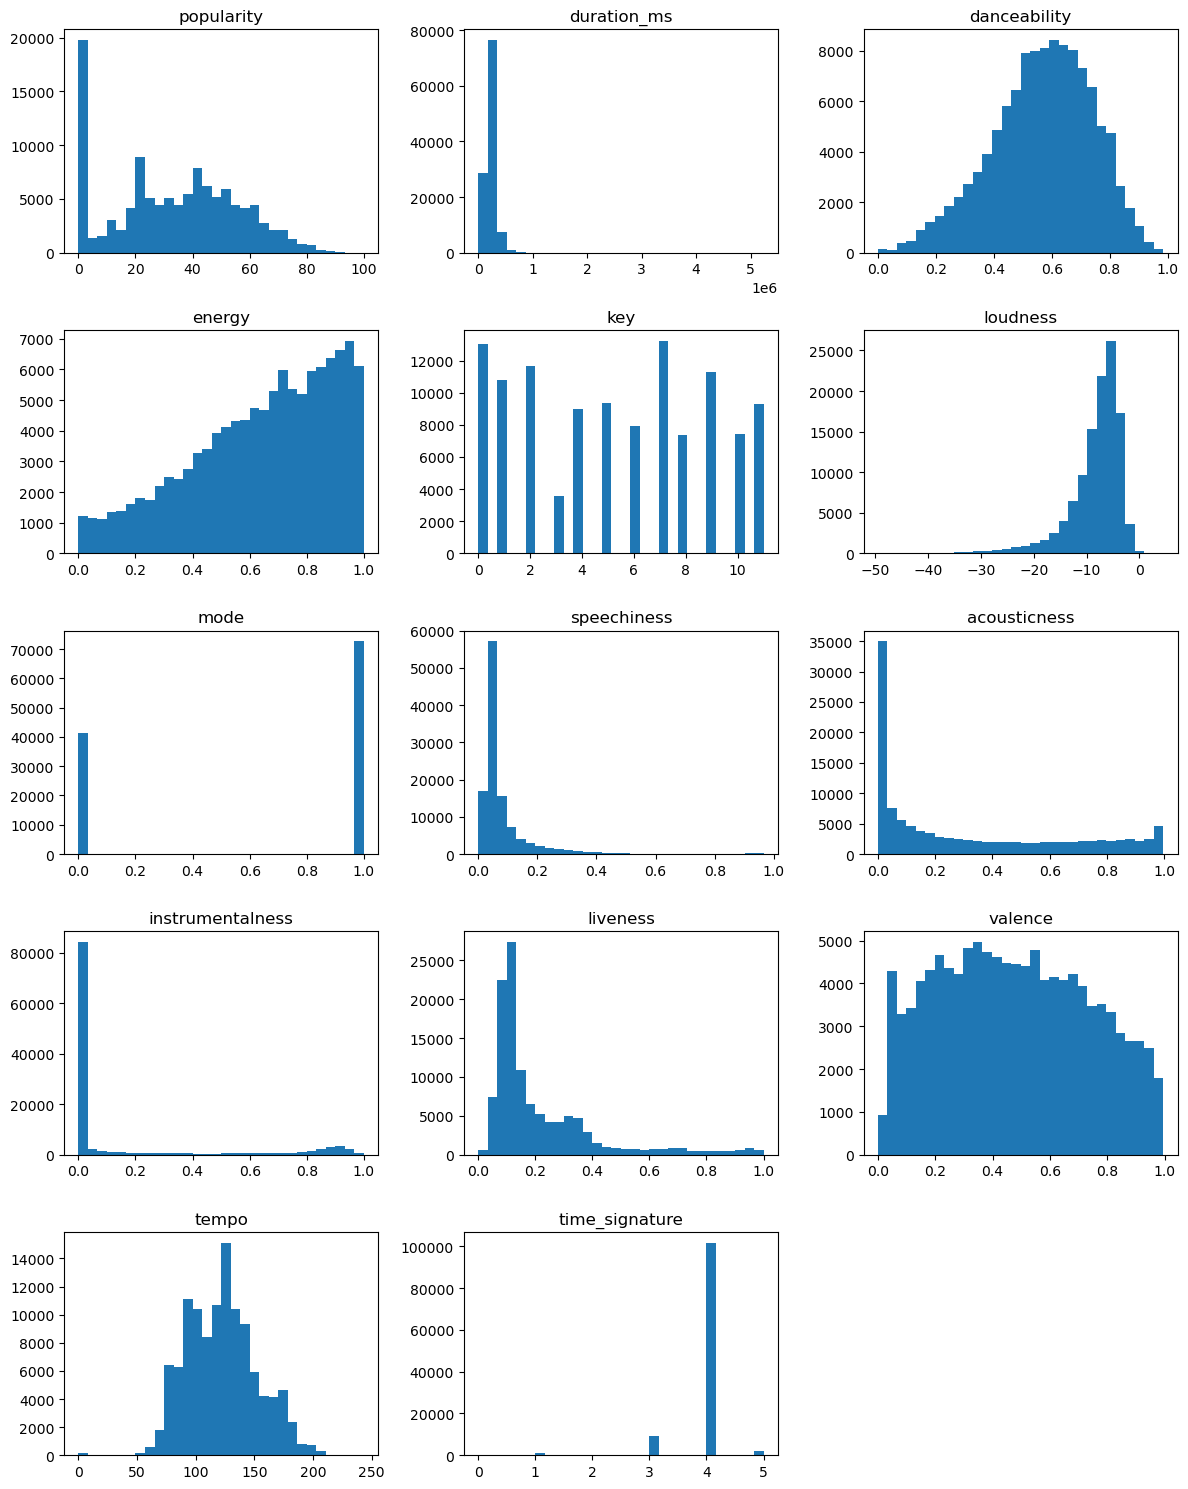

In [17]:
plot_histograms(df, feature_names)

## Explore Relationships Between Features

Scatter plots are used to examine the relationships between selected numerical features. This visualization helps identify potential correlations, clusters, and overlapping patterns, providing an initial indication of how well different genres may be distinguished using the available audio features.

In [18]:
selected_features = [
    name for name in ['danceability', 'energy', 'acousticness', 'valence', 'tempo', 'loudness']
    if name in feature_names
]

selected_features

['danceability', 'energy', 'acousticness', 'valence', 'tempo', 'loudness']

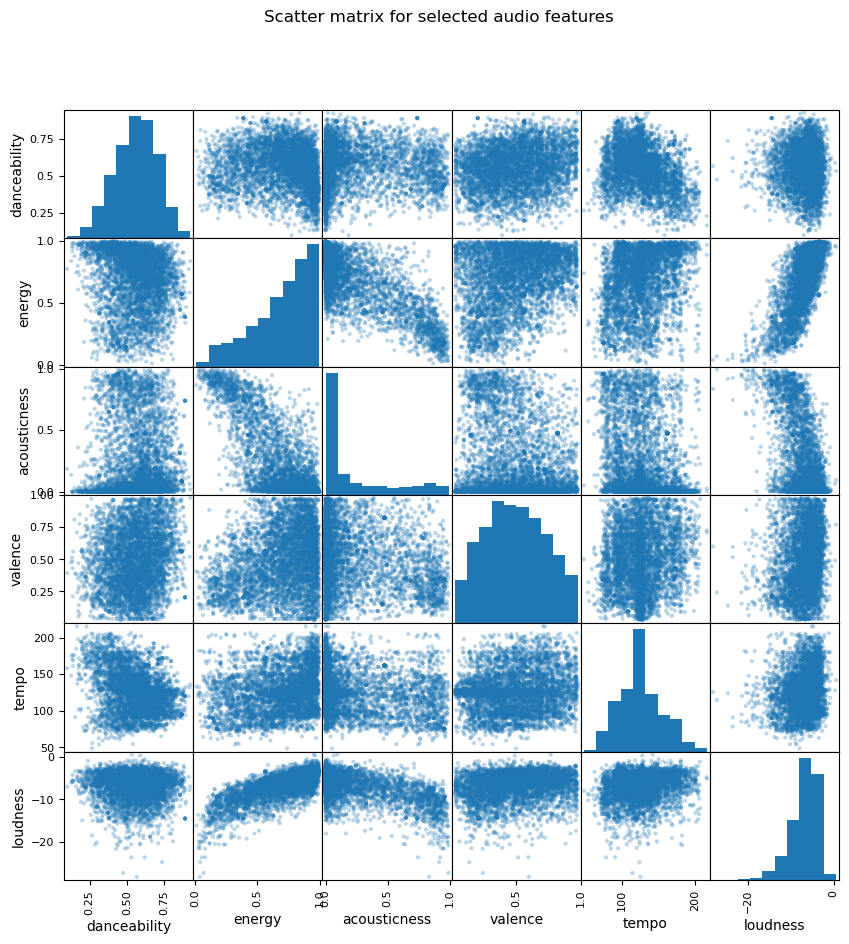

In [19]:
top_genres = Y.value_counts().head(5).index
df_top = df[df[target_name].isin(top_genres)]

pd.plotting.scatter_matrix(
    df_top[selected_features],
    figsize=(10, 10),
    diagonal='hist',
    alpha=0.3
)
plt.suptitle('Scatter matrix for selected audio features')
plt.show()

## Compare Feature Distributions Across Genres

The distributions of selected numerical features are compared across different musical genres to identify characteristic patterns and assess how much the genres overlap in the feature space.

In [20]:
def plot_feature_by_class(df, feature_name, target_name, class_names):
    values = [df[df[target_name] == c][feature_name].dropna().values for c in class_names]

    plt.figure(figsize=(10, 4))
    plt.boxplot(values, tick_labels=class_names, showfliers=False)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel(feature_name)
    plt.title(feature_name + ' by genre')
    plt.tight_layout()
    plt.show()

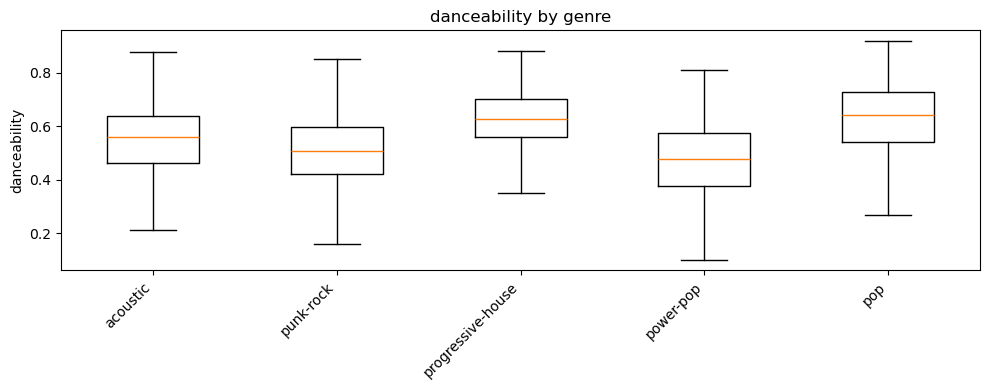

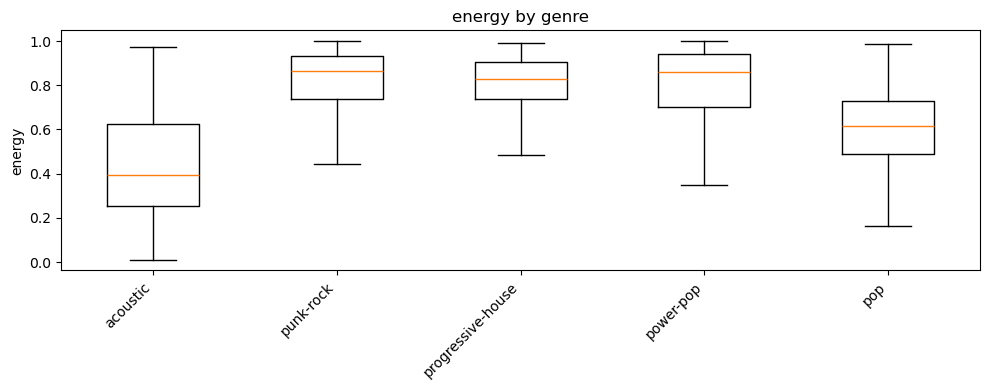

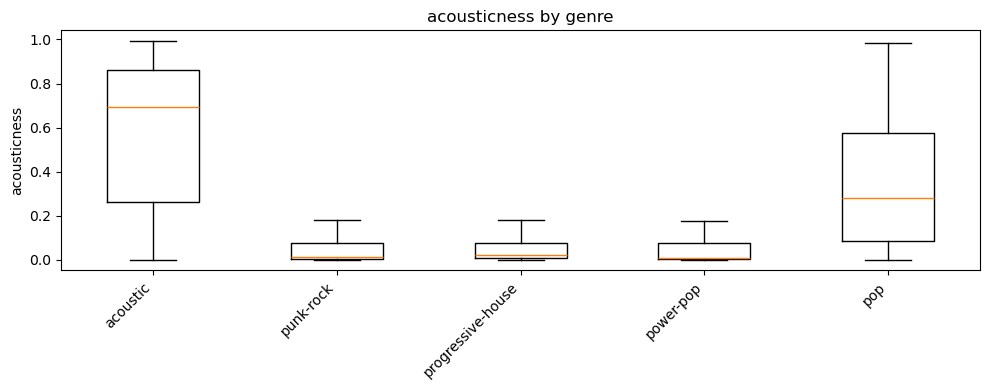

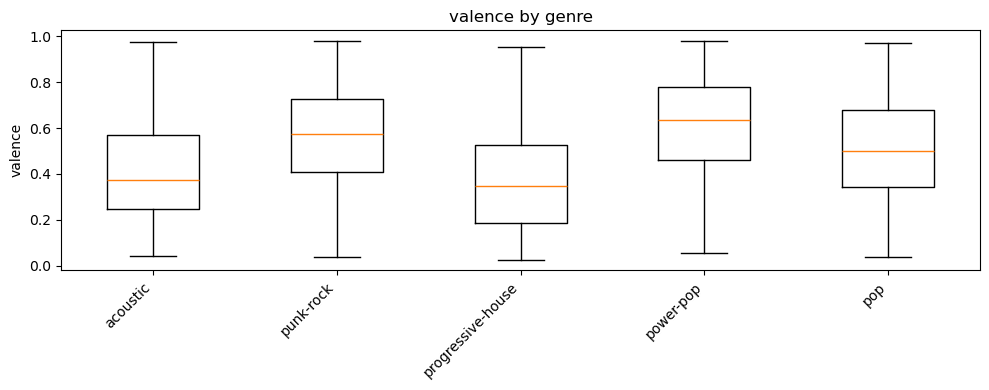

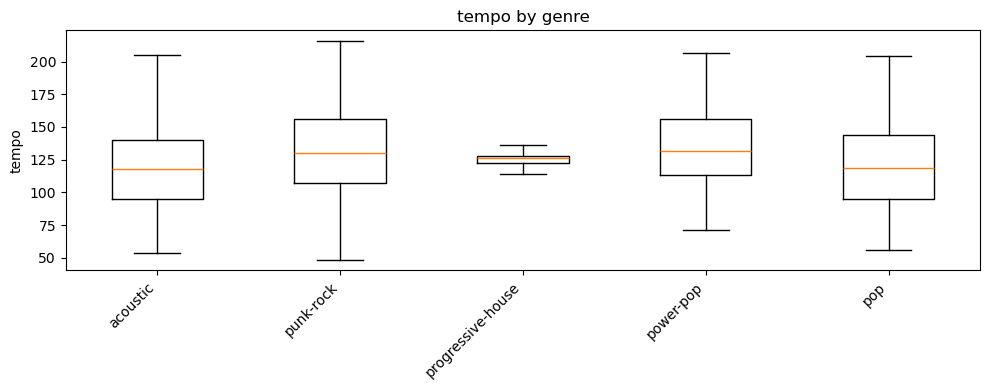

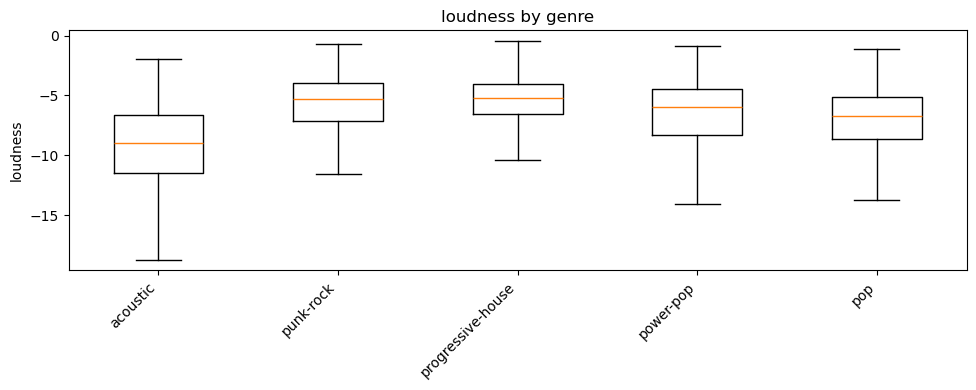

In [21]:
for name in selected_features:
    plot_feature_by_class(df_top, name, target_name, top_genres)

## Analyze Feature Correlations

A correlation matrix is computed to examine the relationships between the numerical features. This analysis helps identify highly correlated variables and provides insight into the overall structure of the dataset before model training.

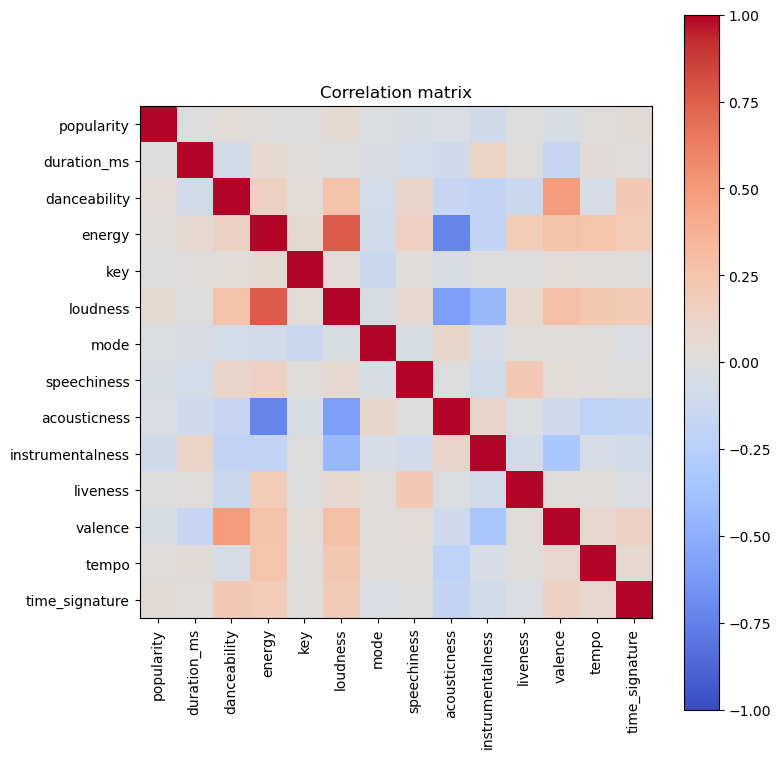

In [22]:
corr = df[feature_names].corr()

plt.figure(figsize=(8, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.yticks(range(len(feature_names)), feature_names)
plt.colorbar()
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

## Correlation Analysis

The correlation matrix reveals several meaningful relationships among the numerical audio features.

As expected, **Energy** and **Loudness** exhibit a strong positive correlation, as more energetic tracks are generally perceived as louder. In contrast, **Acousticness** is negatively correlated with both variables, indicating that acoustic tracks tend to be quieter and less energetic.

Most of the remaining features show weak to moderate correlations, suggesting that they capture complementary aspects of the music. Although **Energy** and **Loudness** are highly correlated, both variables were retained because they may provide complementary information, and tree-based models such as Random Forest are generally robust to multicollinearity.

## Final Notes

The exploratory data analysis provides a clear understanding of the Spotify dataset and its structure before model training.

* The dataset is well-structured, containing 114,000 samples and 21 features, with no significant missing data issues.
* Only a few non-critical missing values were detected in categorical fields (artists, album name and track name).
* The target variable (track_genre) is fully available and balanced across 114 classes, with approximately equal representation per genre.
* Numerical audio features show different distributions and scales, making feature normalization necessary for most machine learning models.
* Visual exploration suggests that some genres can be partially be distinguished based on the selected audio features, although considerable overlap exists between many classes.

Overall, the dataset is suitable for a supervised classification task. However, the high number of genres and the overlap between feature distributions indicate that this is a challenging classification problem, making very high predictive performance difficult to achieve with simple baseline models.